In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import gamma
import torch

# Stochastic Model

In [7]:
N = 100
T = 52
X = np.zeros((T, N))
Y = np.zeros((T, N))
beta = .3
gamma = .1
# X[0, 0] = 1 # seed initial infected patient

X[0][:2] = 1

In [8]:
# frequency dependent: divide force of infection by N
# to do: negative binomial noise for observed cases
for t in range(1, T):
    S = (1 - X[t-1]) * (1 - Y[t-1])
    I = X[t-1] * (1 - Y[t-1])

    # simulate infections
    lam = beta * I.sum() / N
    p_i = 1 - np.exp(-lam)
    X[t] = np.where(S, np.random.binomial(1, p_i, N), X[t-1])

    # observational noise?
    
    # simulate recoveries
    p_r = 1 - np.exp(-gamma)
    Y[t] = np.where(I, np.random.binomial(1, p_r, N), Y[t-1])

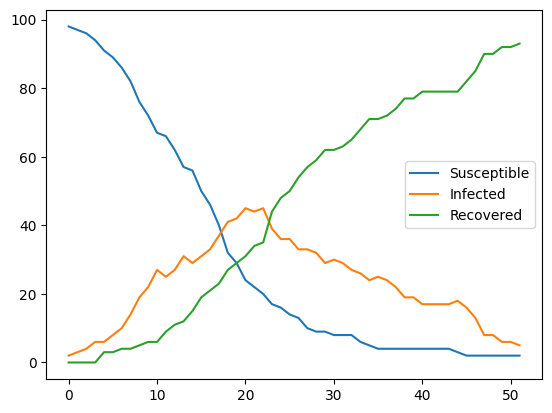

In [9]:
S = N - X.sum(1)
I = X.sum(1) - Y.sum(1)
R = Y.sum(1)

plt.plot(S, label="Susceptible")
plt.plot(I, label="Infected")
plt.plot(R, label="Recovered")
plt.legend()
plt.show()

In [10]:
X.sum(1)

array([ 2.,  3.,  4.,  6.,  9., 11., 14., 18., 24., 28., 33., 34., 38.,
       43., 44., 50., 54., 60., 68., 71., 76., 78., 80., 83., 84., 86.,
       87., 90., 91., 91., 92., 92., 92., 94., 95., 96., 96., 96., 96.,
       96., 96., 96., 96., 96., 97., 98., 98., 98., 98., 98., 98., 98.])

What does the observed data look like? Novel infections?

In [52]:
np.diff(X, axis=0).sum(1)

array([ 0.,  0.,  1.,  1.,  1.,  0.,  1.,  2.,  1.,  0.,  0.,  1.,  0.,
        3.,  0.,  1.,  3.,  0.,  2.,  1.,  4.,  3.,  1.,  3.,  3.,  1.,
        1.,  2.,  2.,  3.,  4.,  3.,  1.,  2.,  2.,  5.,  4.,  5.,  3.,
        2.,  5.,  3.,  2.,  3.,  4.,  2.,  1.,  6.,  5.,  4.,  1.,  7.,
        3.,  3.,  5.,  7.,  3., 10.,  4.,  3.,  1.,  2.,  2.,  0.,  3.,
        6.,  2.,  3.,  5.,  3.,  3.,  3.,  3.,  3.,  2.,  2.,  1.,  2.,
        2.,  0.,  3.,  0.,  4.,  1.,  1.,  2.,  1.,  1.,  1.,  1.,  1.,
        1.,  1.,  1.,  2.,  0.,  1.,  0.,  0.,  1.,  0.,  0.,  3.,  0.,
        0.,  1.,  1.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
        0.,  0.,  0.,  1.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.,  0.,
        0.,  0.,  0.,  0.,  0.,  0.])

# Prior Play

In [94]:
gamma(1, scale=[0.1, 0.1]).rvs((10, 2))

array([[0.0241951 , 0.05351885],
       [0.02447713, 0.05067768],
       [0.01784788, 0.01798345],
       [0.17461643, 0.02780291],
       [0.17369347, 0.00023094],
       [0.12863184, 0.13234039],
       [0.0760451 , 0.02287093],
       [0.10091633, 0.0222377 ],
       [0.0075621 , 0.00908641],
       [0.00411375, 0.18703377]])

In [96]:
gamma(1, scale=0.1).rvs((10, 1))

array([[0.15488237],
       [0.06534882],
       [0.01092838],
       [0.14594163],
       [0.01515166],
       [0.10392727],
       [0.28943679],
       [0.05440766],
       [0.06609954],
       [0.02279587]])

In [93]:
gamma(1, scale=torch.tensor([0.1, 0.1])).rvs((10, 2))

array([[0.05937139, 0.20456122],
       [0.25473628, 0.32448997],
       [0.07796155, 0.25137189],
       [0.23178285, 0.01089943],
       [0.0890174 , 0.25044898],
       [0.00603988, 0.04586459],
       [0.04029883, 0.33715252],
       [0.00741634, 0.18432091],
       [0.02075352, 0.00612617],
       [0.09881145, 0.18477419]])

In [79]:
from torch.distributions import Gamma

In [88]:
Gamma(torch.tensor([1.]), torch.tensor([10])).sample([100]).mean()

tensor(0.1014)

In [104]:
1 / torch.tensor([.1, .1])

tensor([10., 10.])

In [103]:
Gamma(1, torch.tensor([10., 10.])).sample([10])

tensor([[0.1184, 0.1196],
        [0.2474, 0.0926],
        [0.1299, 0.0477],
        [0.1226, 0.0662],
        [0.1513, 0.1200],
        [0.0620, 0.0069],
        [0.1259, 0.1744],
        [0.1404, 0.5475],
        [0.0105, 0.0058],
        [0.0479, 0.0216]])

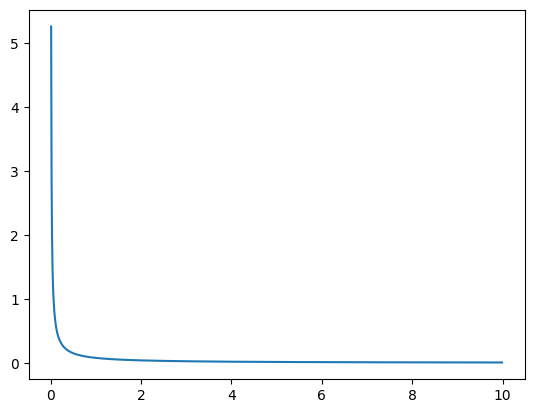

In [63]:
x = np.arange(0, 10, 0.01)
plt.plot(x, gamma.pdf(x, a=.1, scale=10))
plt.show()

In [50]:
help(gamma)

Help on gamma_gen in module scipy.stats._continuous_distns:

<scipy.stats._continuous_distns.gamma_gen object>
    A gamma continuous random variable.

    As an instance of the `rv_continuous` class, `gamma` object inherits from it
    a collection of generic methods (see below for the full list),
    and completes them with details specific for this particular distribution.

    Methods
    -------
    rvs(a, loc=0, scale=1, size=1, random_state=None)
        Random variates.
    pdf(x, a, loc=0, scale=1)
        Probability density function.
    logpdf(x, a, loc=0, scale=1)
        Log of the probability density function.
    cdf(x, a, loc=0, scale=1)
        Cumulative distribution function.
    logcdf(x, a, loc=0, scale=1)
        Log of the cumulative distribution function.
    sf(x, a, loc=0, scale=1)
        Survival function  (also defined as ``1 - cdf``, but `sf` is sometimes more accurate).
    logsf(x, a, loc=0, scale=1)
        Log of the survival function.
    ppf(q, a, l